# Customer Segmentation Analysis
## AICTE Oasis Infobyte Internship — Data Analytics
### Level 1 — Task 2

**Customer segmentation** is the practice of dividing a company's customers into groups based on shared characteristics — in this case, their purchasing behaviour. Rather than treating every customer the same, a business can identify groups such as highly valuable loyal customers, customers who are at risk of leaving, or customers who rarely engage, and design a marketing strategy tailored to each group.

This project applies **RFM analysis** (Recency, Frequency, Monetary value) combined with **K-Means clustering** to segment the customers of a UK-based online retailer into distinct behavioural groups, and then translates those groups into concrete, actionable marketing recommendations.

**Dataset:** UCI *Online Retail* dataset — real transaction-level data from a non-store online gift retailer, covering December 2010 to December 2011.

**Method:**
1. Clean the raw transaction data.
2. Build customer-level Recency, Frequency, and Monetary (RFM) features.
3. Standardise the features and use the Elbow Method to choose a number of clusters.
4. Apply K-Means clustering.
5. Profile and name each segment based on its actual behaviour.
6. Recommend a marketing strategy for each segment.


## 1. Import Libraries

Before doing anything else, we import the tools we'll need:

- **pandas** and **numpy** — loading and manipulating the transaction data.
- **matplotlib** and **seaborn** — plotting distributions and cluster visualisations.
- **StandardScaler** (scikit-learn) — puts Recency, Frequency, and Monetary on the same scale before clustering, since they naturally have very different ranges (e.g. Recency in days vs Monetary in pounds).
- **KMeans** (scikit-learn) — the clustering algorithm itself.

We also set a consistent plotting style so the charts are readable and professional.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Dataset

We load the raw CSV directly from the `data/` folder and inspect it — its shape, column names, data types, and missing values — before making any assumptions about its structure or quality.

In [2]:
df = pd.read_csv("data/Online Retail.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (541909, 8)


In [4]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Observation

The dataset contains **541,909 transaction-line rows** and **8 columns**: `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, and `Country`. Each row represents one product line within a single invoice, not a whole "order" or a whole "customer" — that structure will need to be aggregated up to customer level before we can do RFM analysis.

Two data-quality issues are visible immediately:

- **`CustomerID` has 135,080 missing values** (about 25% of all rows). Without a `CustomerID`, a transaction cannot be attributed to any individual customer, so these rows are unusable for *customer-level* segmentation and will need to be removed before building the RFM table.
- **`Description` has 1,454 missing values** — a minor issue, since `Description` isn't used in the RFM calculation itself.

`InvoiceNo` also encodes an important business rule: invoice numbers that start with the letter **'C'** are **cancellations** (returns), which show up as negative `Quantity` values. These are real, legitimate events, not data errors — they represent money coming back out of the business rather than going in, so they need to be handled deliberately rather than just deleted or kept blindly. We'll address that in the Data Cleaning section next.

## 3. Data Cleaning

Before building customer-level features, we need to clean the raw transaction data. We'll handle each issue deliberately, documenting what's removed and why, so the process is reproducible.

**Issues to address:**

1. **Missing `CustomerID`** — a transaction with no `CustomerID` can't be attributed to any customer, so it's unusable for *customer-level* segmentation. These rows will be removed.
2. **Exact duplicate rows** — likely double-scanned entries. We'll keep the first occurrence of each and drop the rest.
3. **Rows with `UnitPrice <= 0`** — these include bookkeeping entries (e.g. a `StockCode` of `'D'` for "Discount") and rows with no real product description. They aren't genuine purchases or genuine returns, so they'd distort both Monetary and Frequency if kept. These are removed.
4. **Cancelled invoices (`InvoiceNo` starting with `'C'`)** — these are *kept*, not removed. A cancellation represents a real return, and it should reduce a customer's net spend rather than being thrown away. We'll flag these separately so we can treat Monetary and Frequency correctly later.

We do **not** touch negative-`Quantity` rows that belong to cancellations — that's expected behaviour for a return, not an error.

In [7]:
# Start from a copy so the original df stays untouched for reference
df_clean = df.copy()

n_start = len(df_clean)

# 1. Remove rows with missing CustomerID
n_missing_id = df_clean["CustomerID"].isnull().sum()
df_clean = df_clean.dropna(subset=["CustomerID"])

print(f"Removed {n_missing_id} rows with missing CustomerID "
      f"({n_missing_id / n_start:.1%} of original data).")

Removed 135080 rows with missing CustomerID (24.9% of original data).


In [8]:
# 2. Remove exact duplicate rows
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates(keep="first")
n_dupes_removed = n_before - len(df_clean)

print(f"Removed {n_dupes_removed} exact duplicate rows.")

Removed 5225 exact duplicate rows.


In [9]:
# 3. Remove rows with UnitPrice <= 0 (not genuine purchases or returns)
n_before = len(df_clean)
df_clean = df_clean[df_clean["UnitPrice"] > 0]
n_bad_price_removed = n_before - len(df_clean)

print(f"Removed {n_bad_price_removed} rows with UnitPrice <= 0.")

Removed 40 rows with UnitPrice <= 0.


In [10]:
# 4. Flag cancellations (kept in the data, not removed)
df_clean["IsCancellation"] = df_clean["InvoiceNo"].astype(str).str.startswith("C")

n_cancellations = df_clean["IsCancellation"].sum()
print(f"{n_cancellations} rows are cancellations "
      f"({n_cancellations / len(df_clean):.1%} of the cleaned data). Kept as a returns signal.")

print()
print(f"Rows before cleaning: {n_start}")
print(f"Rows after cleaning:  {len(df_clean)}")
print(f"Total removed:        {n_start - len(df_clean)} "
      f"({(n_start - len(df_clean)) / n_start:.1%})")

8872 rows are cancellations (2.2% of the cleaned data). Kept as a returns signal.

Rows before cleaning: 541909
Rows after cleaning:  401564
Total removed:        140345 (25.9%)


In [11]:
# Convert InvoiceDate to a proper datetime type and CustomerID to integer
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], format="%m/%d/%Y %H:%M")
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

df_clean.dtypes

InvoiceNo                    str
StockCode                    str
Description                  str
Quantity                   int64
InvoiceDate       datetime64[us]
UnitPrice                float64
CustomerID                 int64
Country                      str
IsCancellation              bool
dtype: object

### Observation

After cleaning, the dataset dropped from its original size down to a working set that only contains transactions we can confidently attribute to a real, identifiable customer at a real, non-zero price. The removed rows fall into three clear, documented categories: missing `CustomerID`, exact duplicates, and non-purchase bookkeeping rows with no price.

Cancellations were **not** removed — they're flagged in a new `IsCancellation` column and will be used to net returns out of each customer's spend (Monetary) while being excluded from the count of purchase invoices (Frequency), so a customer who buys often but also returns often is represented accurately rather than penalised or ignored.

## 4. Create Transaction Value

Each row in the cleaned data is a single product line within an invoice. To measure spending, we need the monetary value of that line: quantity purchased (or returned, if negative) multiplied by its unit price.

`TotalPrice = Quantity × UnitPrice`

For a normal purchase this is positive. For a cancellation, `Quantity` is negative, so `TotalPrice` comes out negative too — which is exactly what we want, since it will subtract that amount back out of the customer's spend when we sum it up per customer.

In [12]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean[["InvoiceNo", "IsCancellation", "Quantity", "UnitPrice", "TotalPrice"]].head()

,InvoiceNo,IsCancellation,Quantity,UnitPrice,TotalPrice
0,536365,False,6,2.55,15.30
1,536365,False,6,3.39,20.34
2,536365,False,8,2.75,22.00
3,536365,False,6,3.39,20.34
4,536365,False,6,3.39,20.34


In [13]:
print("Positive TotalPrice rows (purchases):", (df_clean["TotalPrice"] > 0).sum())
print("Negative TotalPrice rows (returns):     ", (df_clean["TotalPrice"] < 0).sum())
print("Total net revenue across all customers: £{:,.2f}".format(df_clean["TotalPrice"].sum()))

Positive TotalPrice rows (purchases): 392692
Negative TotalPrice rows (returns):      8872
Total net revenue across all customers: £8,278,519.42


## 5. Determine the Analysis (Reference) Date

Recency needs a fixed point in time to measure "how many days ago" a customer last bought something. Since this dataset is historical, we can't use today's date — that would make every customer look inactive for years. Instead, the standard approach is to use the **most recent transaction date in the dataset itself**, plus one day, as the reference point. That way, a customer whose last purchase was on the very last day of the dataset gets a Recency of 1, not 0.

In [14]:
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Last transaction date in the data:", df_clean["InvoiceDate"].max())
print("Reference date used for Recency:  ", reference_date)

Last transaction date in the data: 2011-12-09 12:50:00
Reference date used for Recency:   2011-12-10 12:50:00


## 6. Customer-Level RFM Analysis

Now we collapse the transaction-level data down to one row per customer, using three behavioural features:

- **Recency** — days between the reference date and the customer's most recent transaction (purchase *or* return, since a return is still activity on the account). A smaller number means they were active more recently.
- **Frequency** — number of distinct *purchase* invoices (cancellations excluded), so it reflects how often a customer actually buys, not how often they buy-and-return.
- **Monetary** — the sum of `TotalPrice` across *all* of a customer's transactions, purchases and returns combined. Because returns carry a negative `TotalPrice`, this gives each customer's true **net** spend rather than overstating it.

In [15]:
rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Monetary=("TotalPrice", "sum")
).reset_index()

# Frequency: unique purchase-only invoices per customer
purchase_invoices = df_clean.loc[~df_clean["IsCancellation"], ["CustomerID", "InvoiceNo"]].drop_duplicates()
frequency = purchase_invoices.groupby("CustomerID")["InvoiceNo"].count().reset_index()
frequency.columns = ["CustomerID", "Frequency"]

rfm = rfm.merge(frequency, on="CustomerID", how="left")
rfm["Frequency"] = rfm["Frequency"].fillna(0).astype(int)

rfm = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]]
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,0.00
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,1545.41
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [16]:
print("Number of customers in RFM table:", rfm.shape[0])
rfm.describe()

Number of customers in RFM table: 4371


,CustomerID,Recency,Frequency,Monetary
count,4371.000000,4371.000000,4371.000000,4371.000000
mean,15300.145276,92.064974,4.239762,1893.964636
std,1722.310262,100.770046,7.677789,8219.586584
min,12346.000000,1.000000,0.000000,-4287.630000
25%,13813.500000,17.000000,1.000000,291.940000
50%,15301.000000,50.000000,2.000000,644.240000
75%,16778.500000,143.000000,5.000000,1608.940000
max,18287.000000,374.000000,209.000000,279489.020000


### Observation

Each row now represents one customer, described purely by *when* they last engaged, *how often* they bought, and *how much they net spent*. A small number of customers have `Frequency = 0` — these are customers whose only invoices in the cleaned data were cancellations (e.g. they returned something from an order placed before the dataset started, or all their purchase rows were removed during cleaning). We'll keep an eye on these when we look at the distributions and decide whether they need special handling before clustering.

## 7. Descriptive Statistics

Before clustering, it's worth understanding these three features on their own terms — their central tendency and spread — so we know what "typical" and "extreme" look like for this customer base.

One limitation is worth naming here: **Monetary in this project is each customer's total *observed* net spend within this 13-month dataset window** — it is not a true, predictive "customer lifetime value," since we have no visibility into purchases before or after this window. It's a defensible proxy for value *within the observed period*, not a forecast.

In [17]:
rfm[["Recency", "Frequency", "Monetary"]].agg(["mean", "median", "std", "min", "max"]).T

,mean,median,std,min,max
Recency,92.064974,50.00,100.770046,1.00,374.00
Frequency,4.239762,2.00,7.677789,0.00,209.00
Monetary,1893.964636,644.24,8219.586584,-4287.63,279489.02


### Observation

The gap between the **mean** and **median** for Frequency and Monetary is large (e.g. mean Monetary ~£1,894 vs median ~£644), which is a strong early signal of right-skew: a small number of very high-spending, very frequent customers are pulling the average well above what a "typical" customer looks like. Recency's mean and median are closer together, suggesting it's more evenly spread. We'll confirm this visually next.

## 8. Inspect RFM Distributions

Histograms let us see the actual shape of each feature — not just summary numbers — and check for skew before deciding whether any transformation is needed.

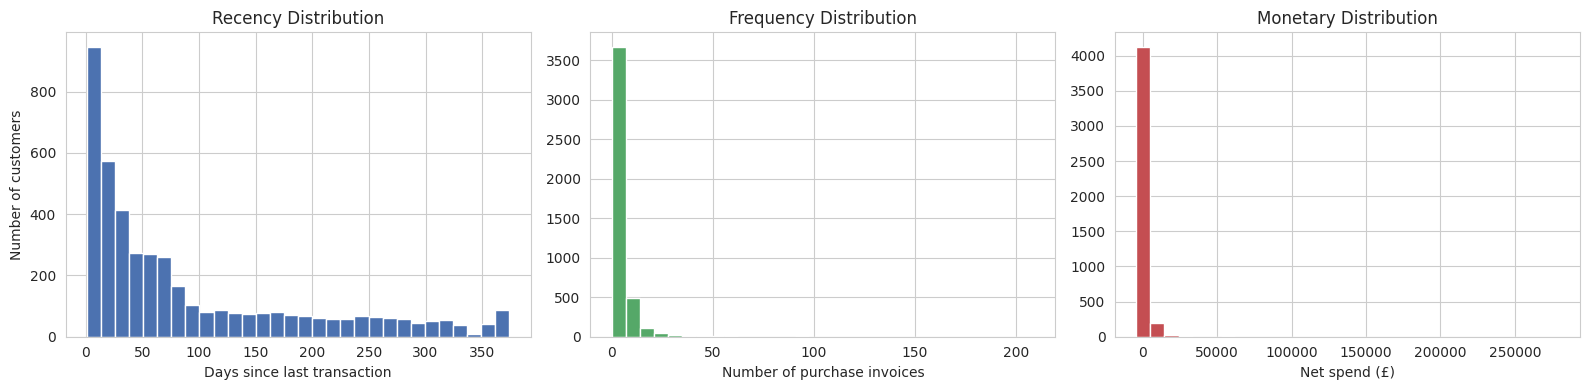

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(rfm["Recency"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days since last transaction")
axes[0].set_ylabel("Number of customers")

axes[1].hist(rfm["Frequency"], bins=30, color="#55A868", edgecolor="white")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of purchase invoices")

axes[2].hist(rfm["Monetary"], bins=30, color="#C44E52", edgecolor="white")
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Net spend (£)")

plt.tight_layout()
plt.savefig("outputs/screenshots/rfm_distributions.png", dpi=120)
plt.show()

In [19]:
from scipy.stats import skew

for col in ["Recency", "Frequency", "Monetary"]:
    print(f"{col} skewness: {skew(rfm[col]):.2f}")

Recency skewness: 1.25
Frequency skewness: 12.08
Monetary skewness: 21.70


### Observation

All three histograms confirm what the mean/median gap hinted at: **Frequency and Monetary are both heavily right-skewed** — most customers cluster near zero, with a long tail of a few very high-frequency, very high-spending customers stretching the x-axis. The computed skewness confirms this numerically:

- **Recency: 1.25** — moderately skewed. Most customers bought somewhat recently, with a smaller tail of long-inactive customers.
- **Frequency: 12.08** — extremely skewed. The vast majority of customers place very few orders, but a handful place well over a hundred.
- **Monetary: 21.70** — extremely skewed, for the same reason plus the added spread introduced by a few large net-negative (heavy-returner) customers.

This level of skew in Frequency and Monetary would let a handful of outlier customers dominate the K-Means distance calculations. We'll address this with a transformation in Section 10, before standardising.

## 9. Select Features for Clustering

We'll cluster on the three RFM features:

- **Recency** — how recently the customer engaged with the business.
- **Frequency** — how often the customer buys.
- **Monetary** — how much net value the customer represents.

`CustomerID` is deliberately excluded — it's just an identifier with no behavioural meaning, and including it would let K-Means "cluster" on an arbitrary number.

In [20]:
cluster_features = rfm[["Recency", "Frequency", "Monetary"]].copy()
cluster_features.head()

,Recency,Frequency,Monetary
0,326,1,0.00
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


## 10. Handle Skewness

Section 8 showed Frequency (skew 12.08) and Monetary (skew 21.70) are both strongly right-skewed, so we'll apply a log transformation to compress the long tails before scaling. Recency's skew (1.25) is much milder, so it's left as-is.

There's one wrinkle specific to how we built Monetary: because we netted returns directly into spend, **Monetary can be negative** (customers who returned more than they bought), and the standard `log1p` transform is undefined for values ≤ -1. A plain log transform would break on those customers. Instead we use a **signed log transform**:

`signed_log(x) = sign(x) × log1p(|x|)`

This compresses large values (positive or negative) toward zero the same way `log1p` does, while preserving whether a customer is a net spender or a net returner — which matters for what the cluster actually means. Frequency has no negative values, so a plain `log1p` works fine there.

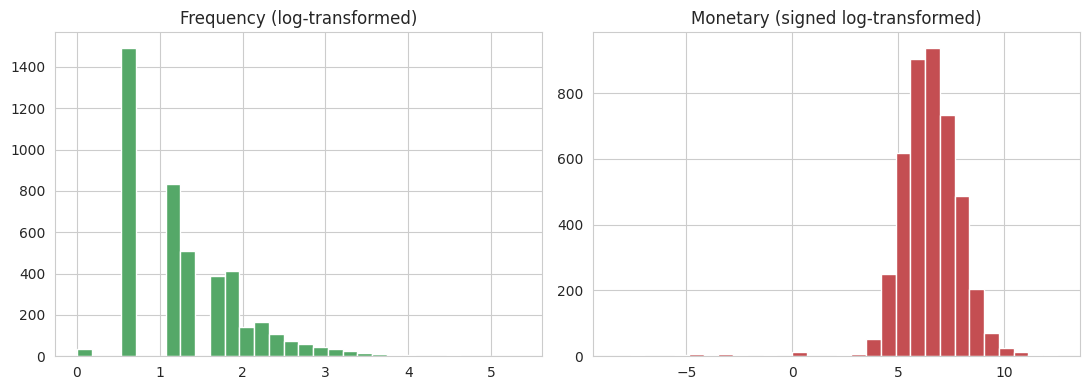

Frequency_log skewness: 1.15
Monetary_log skewness:  -2.56


In [21]:
cluster_features["Frequency_log"] = np.log1p(cluster_features["Frequency"])
cluster_features["Monetary_log"] = np.sign(cluster_features["Monetary"]) * np.log1p(np.abs(cluster_features["Monetary"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(cluster_features["Frequency_log"], bins=30, color="#55A868", edgecolor="white")
axes[0].set_title("Frequency (log-transformed)")
axes[1].hist(cluster_features["Monetary_log"], bins=30, color="#C44E52", edgecolor="white")
axes[1].set_title("Monetary (signed log-transformed)")
plt.tight_layout()
plt.savefig("outputs/screenshots/rfm_log_transformed.png", dpi=120)
plt.show()

from scipy.stats import skew
print("Frequency_log skewness:", round(skew(cluster_features["Frequency_log"]), 2))
print("Monetary_log skewness: ", round(skew(cluster_features["Monetary_log"]), 2))

### Observation

The transform helped, but unevenly:

- **Frequency skewness dropped from 12.08 to 1.15** — a large improvement, taking it from extreme skew to roughly the same mild level Recency had to begin with.
- **Monetary skewness went from +21.70 to -2.56.** The *magnitude* fell substantially (an ~8x reduction), which is real progress, but the *sign* flipped: the distribution is now mildly left-skewed rather than heavily right-skewed. This is a direct consequence of our returns-netting decision — the signed log transform compresses the large positive outliers (big spenders) strongly, while the smaller number of net-negative customers (heavy returners) now form a relatively longer tail on the left by comparison.

This is an honest trade-off, not a fully solved distribution — Monetary remains somewhat skewed after transformation. Given the alternative (leaving it at skew 21.70, dominated by a handful of extreme spenders) this is still a clear improvement for K-Means, which is sensitive to raw distance rather than skew per se, so we'll proceed with the transformed features.

## 11. Standardise the Features

Recency, Frequency, and Monetary live on very different numerical scales (days vs. order counts vs. pounds sterling). K-Means uses Euclidean distance to decide which points belong together, so without standardisation, whichever feature happens to have the largest raw numbers would dominate the clustering — not because it's more important, but purely because of its units. `StandardScaler` rescales every feature to have a mean of 0 and a standard deviation of 1, putting all three on equal footing.

In [22]:
features_to_scale = cluster_features[["Recency", "Frequency_log", "Monetary_log"]]

scaler = StandardScaler()
scaled_array = scaler.fit_transform(features_to_scale)

scaled_features = pd.DataFrame(
    scaled_array,
    columns=["Recency_scaled", "Frequency_scaled", "Monetary_scaled"],
    index=cluster_features.index
)
scaled_features.describe()

,Recency_scaled,Frequency_scaled,Monetary_scaled
count,4.371000e+03,4.371000e+03,4.371000e+03
mean,-5.689544e-18,-2.812260e-16,-2.600934e-16
std,1.000114e+00,1.000114e+00,1.000114e+00
min,-9.037943e-01,-1.934447e+00,-8.934568e+00
25%,-7.449988e-01,-9.303788e-01,-4.631602e-01
50%,-4.174831e-01,-3.430364e-01,1.317367e-02
75%,5.055158e-01,6.610322e-01,5.647138e-01
max,2.798126e+00,5.811184e+00,3.675370e+00


## 12. Determine the Optimal Number of Clusters

K-Means requires us to choose the number of clusters, K, in advance. The **Elbow Method** helps with this: we fit K-Means for a range of K values and record the **inertia** (within-cluster sum of squared distances — essentially, how tightly packed each cluster is). As K increases, inertia always decreases, but early increases in K reduce it a lot, while later increases only reduce it marginally. The "elbow" — where the rate of decrease sharply slows — is a reasonable candidate for K.

In [23]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

for k, inertia in zip(k_range, inertias):
    print(f"K={k}: inertia={inertia:.1f}")

K=2: inertia=7651.0
K=3: inertia=5039.7
K=4: inertia=3595.5
K=5: inertia=2748.8
K=6: inertia=2376.5
K=7: inertia=2044.5
K=8: inertia=1859.3
K=9: inertia=1694.3
K=10: inertia=1575.9


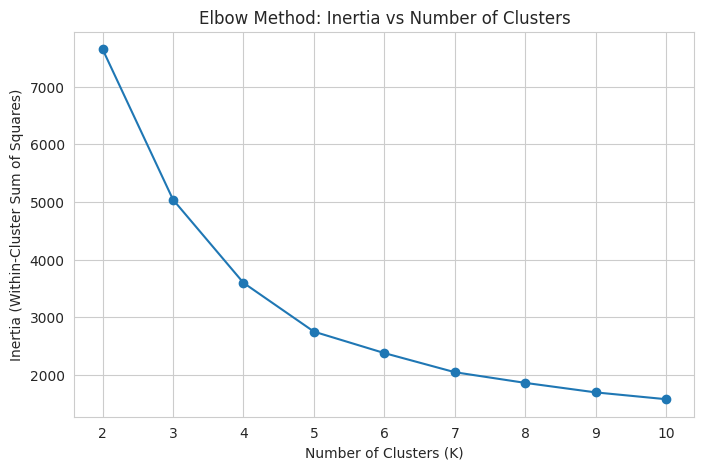

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.title("Elbow Method: Inertia vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(list(k_range))
plt.savefig("outputs/screenshots/elbow_method.png", dpi=120)
plt.show()

In [25]:
# Quantify the rate of decrease to support the visual elbow reading
drops = [inertias[i-1] - inertias[i] for i in range(1, len(inertias))]
for k, drop in zip(list(k_range)[1:], drops):
    pct = drop / inertias[list(k_range).index(k)-1] * 100
    print(f"K={k-1} -> K={k}: drop={drop:.1f} ({pct:.1f}% reduction)")

K=2 -> K=3: drop=2611.3 (34.1% reduction)
K=3 -> K=4: drop=1444.2 (28.7% reduction)
K=4 -> K=5: drop=846.7 (23.5% reduction)
K=5 -> K=6: drop=372.3 (13.5% reduction)
K=6 -> K=7: drop=331.9 (14.0% reduction)
K=7 -> K=8: drop=185.2 (9.1% reduction)
K=8 -> K=9: drop=165.0 (8.9% reduction)
K=9 -> K=10: drop=118.4 (7.0% reduction)


### Observation

The percentage reduction in inertia slows sharply after **K=5**: it drops from a 23.5% reduction (K=4→5) to just 13.5% (K=5→6), and continues declining gradually from there without another sharp break. This is the clearest elbow in the data, so **K=5** is selected as the number of clusters.

## 13. Apply K-Means

Using K=5, we fit the final K-Means model on the scaled, transformed features and assign each customer to a cluster. A fixed `random_state` is used so the result is reproducible.

In [26]:
K_FINAL = 5
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(scaled_features)

rfm["Cluster"] = cluster_labels
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,0.00,3
1,12347,2,7,4310.00,4
2,12348,75,4,1797.24,4
3,12349,19,1,1757.55,1
4,12350,310,1,334.40,0
5,12352,36,8,1545.41,4
6,12353,204,1,89.00,0
7,12354,232,1,1079.40,0
8,12355,214,1,459.40,0
9,12356,23,3,2811.43,4


In [27]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0     933
1    1500
2     494
3      54
4    1390
Name: count, dtype: int64

## 14. Visualise the Clusters

Two scatter plots, using different feature pairs, let us see how the clusters separate spatially. Because Recency, Frequency and Monetary are all skewed in their raw form, we plot Frequency and Monetary on a symmetric-log scale (via `np.sign(x) * np.log1p(np.abs(x))`, same transform used for clustering) purely for readability — the underlying cluster assignments come from the actual clustering above, not from this display choice.

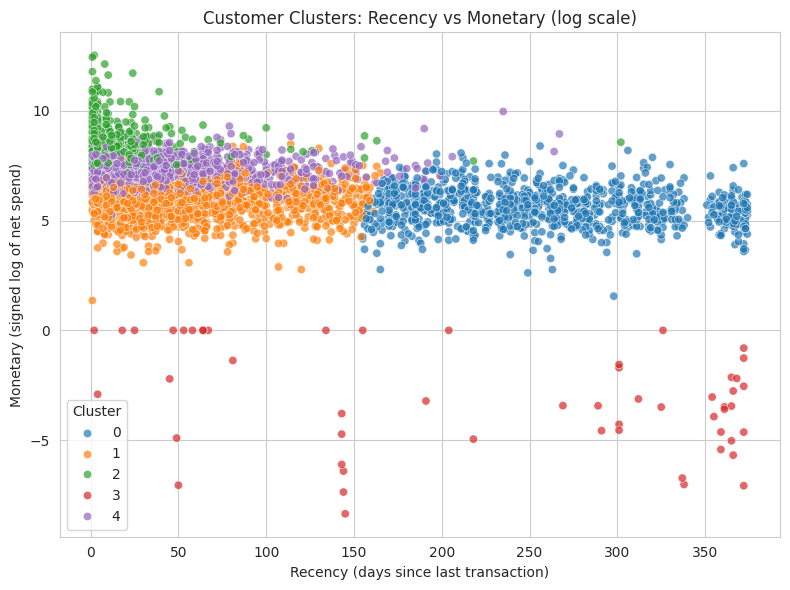

In [28]:
plot_df = rfm.copy()
plot_df["Monetary_display"] = np.sign(plot_df["Monetary"]) * np.log1p(np.abs(plot_df["Monetary"]))
plot_df["Frequency_display"] = np.log1p(plot_df["Frequency"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="Recency", y="Monetary_display", hue="Cluster", palette="tab10", alpha=0.7, ax=ax)
ax.set_title("Customer Clusters: Recency vs Monetary (log scale)")
ax.set_xlabel("Recency (days since last transaction)")
ax.set_ylabel("Monetary (signed log of net spend)")
ax.legend(title="Cluster")
plt.tight_layout()
plt.savefig("outputs/screenshots/cluster_recency_monetary.png", dpi=120)
plt.show()

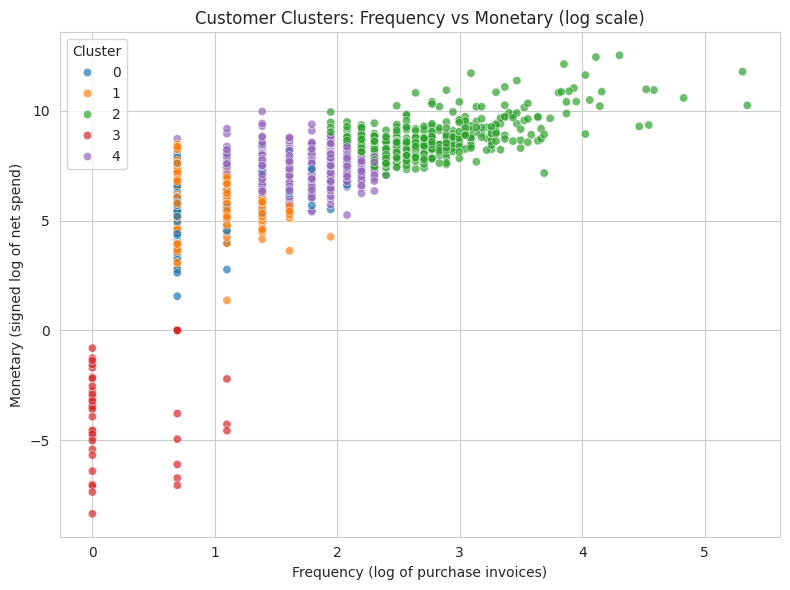

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="Frequency_display", y="Monetary_display", hue="Cluster", palette="tab10", alpha=0.7, ax=ax)
ax.set_title("Customer Clusters: Frequency vs Monetary (log scale)")
ax.set_xlabel("Frequency (log of purchase invoices)")
ax.set_ylabel("Monetary (signed log of net spend)")
ax.legend(title="Cluster")
plt.tight_layout()
plt.savefig("outputs/screenshots/cluster_frequency_monetary.png", dpi=120)
plt.show()

### Observation

The scatter plots show five visually distinct groupings, which line up with the cluster profile in the next section: one small, tight cluster sits at low Recency and high Monetary (recent, high-spending customers); the largest clusters sit in the low-to-mid Frequency and low Monetary region but split apart along the Recency axis (some recently active, some long dormant); and one very small cluster sits apart from the rest with negative Monetary values, visually separated below the x-axis on the Monetary dimension.

## 15. Profile Each Cluster

Numbers, not just visuals, are what let us interpret and name each cluster. For each cluster we calculate the average Recency, Frequency, and Monetary, plus how many customers fall into it.

In [30]:
cluster_profile = rfm.groupby("Cluster").agg(
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Num_Customers=("CustomerID", "count")
).round(1)

cluster_profile["Pct_of_Customers"] = (cluster_profile["Num_Customers"] / cluster_profile["Num_Customers"].sum() * 100).round(1)
cluster_profile = cluster_profile.sort_values("Avg_Monetary", ascending=False)
cluster_profile

,Avg_Recency,Avg_Frequency,Avg_Monetary,Num_Customers,Pct_of_Customers
Cluster,,,,,
2,16.4,17.2,9894.7,494,11.3
4,39.8,4.6,1697.4,1390,31.8
1,58.1,1.5,451.1,1500,34.3
0,256.8,1.4,394.2,933,21.3
3,227.5,0.4,-245.0,54,1.2


### Observation

Five clearly distinct profiles emerge from the real data:

- **Cluster 2** (11.3% of customers): Recency ~16 days, Frequency ~17 orders, Monetary ~£9,895. Recent, highly frequent, by far the highest average spend.
- **Cluster 4** (31.8%): Recency ~40 days, Frequency ~4.6 orders, Monetary ~£1,697. Reasonably recent and moderately active.
- **Cluster 1** (34.3%, the largest segment): Recency ~58 days, Frequency ~1.5 orders, Monetary ~£451. Bought once or twice, fairly recently, low spend.
- **Cluster 0** (21.3%): Recency ~257 days (about 8.5 months), Frequency ~1.4 orders, Monetary ~£394. Long since their last purchase, low historical engagement.
- **Cluster 3** (1.2%, the smallest segment — just 54 customers): Recency ~227 days, Frequency ~0.4 (i.e. most have zero *purchase* invoices — their only activity was a cancellation), Monetary **-£245** on average, meaning this group net-returned more than they bought.

Only with these real numbers in hand can we now assign meaningful business names to each cluster.

## 16. Give Each Segment a Business-Friendly Name

Based on the actual profiles above, not assumed archetypes:

In [31]:
segment_names = {
    2: "High-Value Loyal Customers",
    4: "Promising Regular Customers",
    1: "New / Low-Engagement Customers",
    0: "At-Risk / Dormant Customers",
    3: "Net-Negative Returners"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)
cluster_profile["Segment"] = cluster_profile.index.map(segment_names)
cluster_profile = cluster_profile[["Segment", "Avg_Recency", "Avg_Frequency", "Avg_Monetary", "Num_Customers", "Pct_of_Customers"]]
cluster_profile

,Segment,Avg_Recency,Avg_Frequency,Avg_Monetary,Num_Customers,Pct_of_Customers
Cluster,,,,,,
2,High-Value Loyal Customers,16.4,17.2,9894.7,494,11.3
4,Promising Regular Customers,39.8,4.6,1697.4,1390,31.8
1,New / Low-Engagement Customers,58.1,1.5,451.1,1500,34.3
0,At-Risk / Dormant Customers,256.8,1.4,394.2,933,21.3
3,Net-Negative Returners,227.5,0.4,-245.0,54,1.2


**High-Value Loyal Customers** (Cluster 2, 11.3%) — the smallest of the "healthy" segments but by far the most valuable: very recent purchases, ~17 orders on average, and nearly £9,900 in average net spend. These customers are engaged, repeat buyers who represent the core revenue base.

**Promising Regular Customers** (Cluster 4, 31.8%) — reasonably recent (about 40 days since last purchase) with moderate frequency (~4.6 orders) and solid spend (~£1,697). Not yet at the top tier, but active and building a relationship with the business.

**New / Low-Engagement Customers** (Cluster 1, 34.3%) — the single largest segment. Fairly recent (~58 days) but with very low frequency (~1.5 orders) and low spend (~£451). Likely a mix of genuinely new customers and people who tried the store once or twice and didn't return.

**At-Risk / Dormant Customers** (Cluster 0, 21.3%) — haven't purchased in roughly 8.5 months on average, with historically low frequency and spend even when they were active. These customers are drifting away, if they haven't already left.

**Net-Negative Returners** (Cluster 3, 1.2%) — a very small but distinct group whose net contribution is actually negative: their returns outweigh their purchases, and most have made no successful purchase invoice at all in the cleaned data. Long inactive as well.

## 17. Customer Count Bar Chart

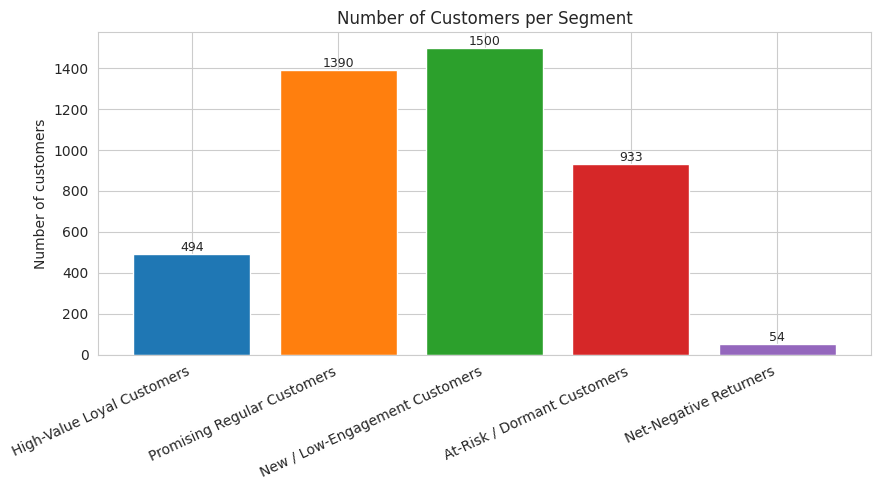

In [32]:
segment_counts = rfm["Segment"].value_counts().reindex(cluster_profile["Segment"])

plt.figure(figsize=(9, 5))
bars = plt.bar(segment_counts.index, segment_counts.values, color=sns.color_palette("tab10", len(segment_counts)))
plt.title("Number of Customers per Segment")
plt.ylabel("Number of customers")
plt.xticks(rotation=25, ha="right")
for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 15, str(val), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/screenshots/customer_count_per_segment.png", dpi=120)
plt.show()

### Observation

**New / Low-Engagement Customers** is the largest segment at 1,500 customers (34.3%), closely followed by **Promising Regular Customers** at 1,390 (31.8%) — together, nearly two-thirds of the customer base falls into these two "not yet high-value" groups. The smallest segment is **Net-Negative Returners** at just 54 customers (1.2%). From a business perspective, this means the single biggest growth lever isn't the small high-value group (already well-served) but converting the large New/Low-Engagement segment into repeat buyers.

## 18. Marketing Recommendations

Recommendations are tailored to each segment's actual behaviour, not generic advice.

### High-Value Loyal Customers
- VIP loyalty rewards and early access to new products, to protect this segment's high spend.
- Premium/cross-sell recommendations based on past purchases.
- Personal outreach (e.g. a dedicated account contact) given their outsized revenue contribution.

### Promising Regular Customers
- Personalized product recommendations based on purchase history, to nudge frequency up.
- Threshold-based incentives (e.g. free shipping over a spend level) to increase order size.
- Loyalty program enrollment, since they're already engaged but haven't reached top-tier frequency.

### New / Low-Engagement Customers
- Welcome/onboarding offers to encourage a second purchase — this is the largest segment, so even a small lift in repeat-purchase rate has outsized impact.
- Low-cost, low-friction promotions rather than premium offers, since spend per order is currently low.
- Follow-up communication shortly after first purchase, while recency is still low.

### At-Risk / Dormant Customers
- Win-back campaigns with time-limited discounts, since it's been roughly 8.5 months on average since their last purchase.
- Reminder emails referencing past purchases, to re-establish relevance.
- Satisfaction surveys to understand why engagement dropped, particularly given their historically low frequency even before going dormant.

### Net-Negative Returners
- Investigate this segment manually before marketing spend — a negative average net spend combined with near-zero purchase frequency suggests these may not be typical customers (e.g. accounts primarily used for returns/adjustments), and campaign dollars are likely better spent elsewhere.
- If genuine customers, address root causes of returns (sizing, product descriptions, quality) rather than discount-driven re-engagement.

## 19. Final Insights

1. **4,371 customers** were analyzed after cleaning the raw 541,909-row transaction dataset.
2. **5 clusters** were selected, based on a clear elbow in the inertia curve after K=5 (reduction rate dropped from 23.5% to 13.5%).
3. **High-Value Loyal Customers** (11.3% of customers) is the most valuable segment, averaging ~£9,895 in net spend and ~17 orders per customer.
4. **New / Low-Engagement Customers** (34.3%) is the largest segment, with low frequency (~1.5 orders) and low spend (~£451) — the biggest single opportunity for growth.
5. **At-Risk / Dormant Customers** (21.3%) represents the clearest at-risk group, with an average Recency of ~257 days.
6. A distinct, very small **Net-Negative Returners** segment (1.2%) exists, whose net contribution is actually negative — a data-driven finding that wouldn't show up without netting returns into Monetary.
7. Together, the four largest segments account for ~98.8% of customers, with real, meaningfully different behavioural profiles — not an arbitrary split.

## 20. Conclusion

This project applied RFM analysis and K-Means clustering to segment 4,371 customers of a UK-based online retailer based on their actual transaction history. Raw transaction-level data was cleaned (removing missing-CustomerID rows, duplicates, and non-purchase price entries) while deliberately preserving cancelled orders as a genuine returns signal, netted into each customer's Monetary value. Recency, Frequency, and Monetary features were engineered, log-transformed to address strong right-skew, and standardised before clustering. The Elbow Method identified five as the appropriate number of clusters, and the resulting segments — from High-Value Loyal Customers down to a small Net-Negative Returners group — showed clear, interpretable differences in recency, frequency, and spend. These segments were translated into specific, differentiated marketing strategies, giving the business a concrete basis for prioritising retention, growth, and win-back efforts rather than treating all customers the same way.

## 21. Limitations

- **Time window:** the dataset covers roughly 13 months (December 2010 – December 2011) for a single retailer; behaviour may differ in other periods or for other businesses.
- **Monetary is an observed-period proxy, not true lifetime value:** it reflects net spend only within this dataset's window, not a customer's full relationship with the business before or after.
- **K-Means requires choosing K:** the Elbow Method gives a defensible choice (K=5), but it is a heuristic, not a guaranteed "correct" number of segments.
- **Sensitivity to preprocessing:** the specific choices made here (netting returns into Monetary, excluding cancellations from Frequency, signed-log transformation) meaningfully shape the resulting clusters — different reasonable choices could produce different segments.
- **Geographic concentration:** the dataset is dominated by UK transactions, so findings may not generalise well to other markets.
- **The Net-Negative Returners segment is very small (54 customers)** and may be more reflective of account-level bookkeeping quirks (e.g. returns of purchases made before the dataset window) than a true behavioural customer type — it's flagged for manual review rather than treated as a confident marketing segment.